# omcwa showcase

omcwa loads OpenMovement `.cwa` recordings from AX3 and AX6 devices, runs
auto-calibration, and resamples to uniform NumPy arrays. It vendors
OpenMovement's `omconvert` C code rather than reimplementing it.
`native/VENDORING.md` tracks the local patches on top of that code,
including a real AX6 calibration bug that `omconvert` itself never caught.
`calibration_source="player"` and `on_calibration_failure="identity"` keep
`omconvert`'s original numbers available for pipelines that depend on them.

This notebook runs on the committed synthetic fixtures under
`tests/fixtures/golden/`, so it needs no local recordings or external
binaries.

Install the showcase dependencies before running:

```bash
uv sync --group showcase
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from omcwa import CalibrationError, InterpolateMode, load_cwa, process_cwa

# Works whether Jupyter starts in the repository root or examples/.
FIXTURE_DIR = Path("tests/fixtures/golden")
if not FIXTURE_DIR.is_dir():
    FIXTURE_DIR = Path("../tests/fixtures/golden")

CAL_SUCCESS = FIXTURE_DIR / "cal_success.cwa"
CAL_FAILURE = FIXTURE_DIR / "cal_failure.cwa"
CAL_FAILURE_NO_AXIS = FIXTURE_DIR / "cal_failure_no_axis.cwa"
RESAMPLE_ONLY = FIXTURE_DIR / "resample_only.cwa"

for fixture in (CAL_SUCCESS, CAL_FAILURE, CAL_FAILURE_NO_AXIS, RESAMPLE_ONLY):
    if not fixture.is_file():
        raise FileNotFoundError(f"Fixture not found: {fixture}")

print(f"Using fixtures from: {FIXTURE_DIR}")

Using fixtures from: ../tests/fixtures/golden


## Load, resample, look at the signal

`resample_only.cwa` holds five seconds of known multi-frequency sinusoids at
its 100 Hz file rate, with no calibration content. `load_cwa` returns it
uncalibrated at that file rate; `process_cwa` resamples the same file to an
arbitrary rate and interpolation mode in one call.

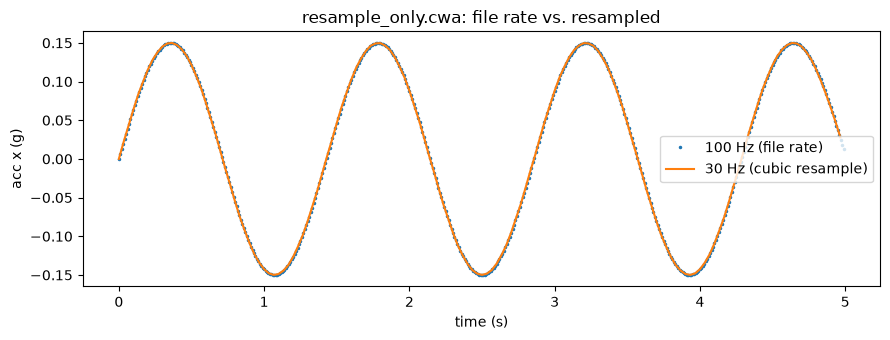

In [2]:
raw = load_cwa(RESAMPLE_ONLY)
smooth = process_cwa(
    RESAMPLE_ONLY,
    calibrate=False,
    sample_rate_hz=30.0,
    interpolate=InterpolateMode.CUBIC,
)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(
    raw.time - raw.time[0],
    raw.acc[:, 0],
    ".",
    ms=3,
    label=f"{raw.sample_rate_hz:.0f} Hz (file rate)",
)
ax.plot(
    smooth.time - smooth.time[0],
    smooth.acc[:, 0],
    "-",
    lw=1.5,
    label=f"{smooth.sample_rate_hz:.0f} Hz (cubic resample)",
)
ax.set_xlabel("time (s)")
ax.set_ylabel("acc x (g)")
ax.set_title("resample_only.cwa: file rate vs. resampled")
ax.legend()
fig.tight_layout()

## Default strict pipeline

The default uses cubic interpolation at the file rate. The successful fixture
contains enough stationary orientations for auto-calibration to converge.

In [3]:
default_out = process_cwa(CAL_SUCCESS)
cal = default_out.calibration

print(f"sample rate: {default_out.sample_rate_hz} Hz")
print(f"acc shape: {default_out.acc.shape} (g)")
print(f"gyr shape: {default_out.gyr.shape} (dps)")
print(f"calibration success: {cal.success}")
print(f"calibration error code: {cal.error_code}")
print(f"stationary points used: {cal.num_stationary_points}")
print(f"axes covered: {cal.num_axes}")
print(f"mean SVM fit error: {cal.mean_svm_error:.6f}")
print(f"metadata keys: {sorted(default_out.metadata)}")

sample rate: 100.0 Hz
acc shape: (8000, 3) (g)
gyr shape: (8000, 3) (dps)
calibration success: True
calibration error code: 0
stationary points used: 7
axes covered: 3
mean SVM fit error: 0.090507
metadata keys: ['change_time', 'channels', 'clear_time', 'config_accel_frequency', 'config_accel_sensitivity', 'default_rate', 'device_id', 'device_type', 'device_version', 'end_time', 'firmware', 'has_accel', 'has_gyro', 'has_mag', 'metadata', 'num_channels', 'recording_start', 'recording_stop', 'sample_rate_hz', 'session_id', 'start_time']


## The default calibration path fixes a real omconvert bug

AX6 recordings put gyroscope axes before the accelerometer in each sector.
`omconvert` used the accelerometer's byte offset as a proxy for where to
read calibration temperature, which is wrong on AX6 and forced it through a
slower interpolating "player" pass to get usable numbers.
`calibration_source="data"` (the default) reads temperature from its actual
fixed sector offset and calibrates straight from CWA sectors instead.
`calibration_source="player"` still reproduces `omconvert`'s original path,
so the cell below checks the two against each other.

In [4]:
fast = process_cwa(CAL_SUCCESS, calibration_source="data")
legacy = process_cwa(CAL_SUCCESS, calibration_source="player")

print(
    "stationary points |data|:",
    fast.calibration.num_stationary_points,
)
print(
    "stationary points |player|:",
    legacy.calibration.num_stationary_points,
)
print(
    "max |scale| difference:",
    f"{np.max(np.abs(fast.calibration.scale - legacy.calibration.scale)):.2e}",
)
print(
    "max |acc| difference:",
    f"{np.max(np.abs(fast.acc - legacy.acc)):.2e} g",
)

stationary points |data|: 7
stationary points |player|: 7
max |scale| difference: 0.00e+00
max |acc| difference: 1.69e-08 g


## Strict calibration failures

Failed fits raise `CalibrationError` before resampled output is allocated. The
exception preserves omconvert's native error code.

In [5]:
for fixture in (CAL_FAILURE, CAL_FAILURE_NO_AXIS):
    try:
        process_cwa(fixture)
    except CalibrationError as error:
        print(f"{fixture.name}: {error}")

cal_failure.cwa: omconvert auto-calibration failed with error code -1 (2 stationary points, 0 axes within range, axis_min=[1.5865985893257113e-21, 1.5865985893257113e-21, 0.9998803710937498], axis_max=[1.5865985893257113e-21, 1.5865985893257113e-21, 0.9998803710937498])
cal_failure_no_axis.cwa: omconvert auto-calibration failed with error code -2 (4 stationary points, 0 axes within range, axis_min=[1.5865985893257113e-21, 1.5865985893257113e-21, 0.9998803710937498], axis_max=[1.5865985893257113e-21, 1.5865985893257113e-21, 0.9998803710937498])


## Explicit identity fallback and no-calibration mode

`on_calibration_failure="identity"` accepts omconvert's identity coefficients
but keeps `success=False` and the failure code. `calibrate=False` skips fitting
and reports a successful identity calibration.

In [6]:
fallback = process_cwa(
    CAL_FAILURE,
    on_calibration_failure="identity",
)
no_cal = process_cwa(CAL_FAILURE, calibrate=False)

print(
    "fallback: ",
    fallback.calibration.success,
    fallback.calibration.error_code,
)
print(
    "no calibration: ",
    no_cal.calibration.success,
    no_cal.calibration.error_code,
)
print(f"max accel difference: {np.max(np.abs(fallback.acc - no_cal.acc))}")

fallback:  False -1
no calibration:  True 0
max accel difference: 0.0


## Halving output memory with `dtype="float32"`

`acc` and `gyr` are `float64` by default, matching every consumer today.
Pass `dtype="float32"` to `process_cwa` or `load_cwa` to halve their memory
footprint; `time` stays `float64` regardless, since it carries the full
Unix-epoch magnitude. The two outputs agree to one float32 ULP.

In [7]:
f64 = process_cwa(CAL_SUCCESS, dtype="float64")
f32 = process_cwa(CAL_SUCCESS, dtype="float32")

print(f"float64 acc: {f64.acc.dtype}, {f64.acc.nbytes / 1024:.1f} KiB")
print(f"float32 acc: {f32.acc.dtype}, {f32.acc.nbytes / 1024:.1f} KiB")
print(
    "max |difference|:",
    f"{np.max(np.abs(f64.acc - f32.acc.astype(np.float64))):.2e} g",
)

float64 acc: float64, 187.5 KiB
float32 acc: float32, 93.8 KiB
max |difference|: 5.95e-08 g


## Uncalibrated loading, explicit rate, and output windows

`load_cwa` exposes file-rate acceleration, gyroscope, and temperature with
identity calibration. `process_cwa` accepts a target rate, interpolation mode,
and a half-open Unix-time output range.

In [8]:
uniform = load_cwa(CAL_SUCCESS)
t0 = float(uniform.time[0])

windowed = process_cwa(
    CAL_SUCCESS,
    sample_rate_hz=50.0,
    interpolate=InterpolateMode.LINEAR,
    time_range=(t0 + 1.0, t0 + 3.0),
)

print(f"temperature shape: {uniform.temp.shape} (degrees C)")
print(f"windowed shape: {windowed.acc.shape}")
print(f"windowed rate: {windowed.sample_rate_hz} Hz")
print(f"time bounds: {windowed.time[0]:.2f} .. {windowed.time[-1]:.2f}")

temperature shape: (8000,) (degrees C)
windowed shape: (100, 3)
windowed rate: 50.0 Hz
time bounds: 1577836801.00 .. 1577836802.98


## Current limits and future extension work

The complete first session and output are materialized. `time_range` trims only
after processing, and version 0.1 makes no 1 GB deployment-readiness claim.
Custom backends remain a non-public TODO until a lazy, pre-resample,
chunk-capable `CwaSource` contract is designed.

In [9]:
assert all(not key.startswith("_") for key in default_out.metadata)

print(f"valid samples: {np.count_nonzero(default_out.valid)}")
print(f"clipped samples: {np.count_nonzero(default_out.clipped)}")
print("No native handles or private metadata keys are retained.")

valid samples: 8000
clipped samples: 0
No native handles or private metadata keys are retained.


## Production use

Keep strict calibration failures unless identity fallback is an explicit
data quality policy. Defaults track the fixed, faster calibration path
(`calibration_source="data"`); if a downstream pipeline was validated
against `omconvert`'s original numbers, pin `calibration_source="player"`
explicitly rather than relying on the default staying put. For large
recordings, measure peak memory in the target environment and wait for the
planned native windowing/chunking work before making deployment-scale
guarantees.